1. Preparing your data for evaluate with DataLoaders

In [1]:
import torchvision.transforms.v2 as transforms
import torch
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToImage(),  # Convert to image format
    transforms.ConvertImageDtype(torch.float32),  # Convert image dtype
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))])


test_dataset = ImageFolder("./FruitClassification/test", transform=transform)
test_dataloader = DataLoader(test_dataset, batch_size=4, shuffle=True)

classes = test_dataset.classes
print(classes)

['apple', 'avocado', 'banana', 'cherry', 'kiwi', 'mango', 'orange', 'pinenapple', 'strawberries', 'watermelon']


       - Show sample image from the DataLoader

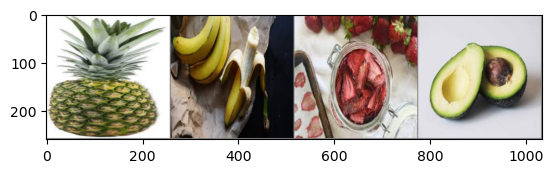

pinenapple banana strawberries avocado


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision


def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(test_dataloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

2. Load a Convolutional Neural Network

In [3]:
from torchvision.models import resnet50, ResNet50_Weights
import torch.nn as nn

# New weights with accuracy 80.858%
model = resnet50()
model.fc = nn.Linear(2048, len(classes))
model.load_state_dict(torch.load('./model.pt'))


<All keys matched successfully>

3. Evaluate the network

In [4]:
from sklearn.metrics import accuracy_score

# Check if GPU (cuda) is available
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# Move our model to device (GPU or CPU)
model.to(device)
model.eval()

correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for inputs, labels in test_dataloader:
        images, labels = inputs.to(device), labels.to(device)

        # calculate outputs by running images through the network
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        correct += accuracy_score(labels.cpu(), predicted.cpu())
        total += 1

print(f'Accuracy of the network on the test images: {100 * correct / total:.02f} %')


Accuracy of the network on the test images: 91.63 %
